# Pengukuran Jarak Data Mahasiswa

Dataset ini merupakan dataset yang berisi data mahasiswa dengan beberapa atribut yang berbeda tipe data. Setiap baris merepresentasikan satu mahasiswa yang mencakup informasi umur, IPK, tingkat stres, metode belajar, serta informasi keikutsertaan organisasi dan akses internet. Dataset ini digunakan untuk mempelajari pengukuran jarak pada data campuran (mixed data).

# Pengukuran Jarak

## Deskripsi Dataset

Dataset yang digunakan dalam praktikum ini adalah dataset mahasiswa yang berisi informasi mengenai karakteristik mahasiswa seperti umur, IPK, tingkat stres, metode belajar, serta aktivitas organisasi. Dataset ini digunakan untuk melakukan analisis pengukuran jarak antar objek dengan tipe data campuran (mixed data types), yaitu numerik, ordinal, kategorikal, dan binary. Jumlah data dalam dataset ini adalah **100 baris** dengan **7 atribut**.

## Klasifikasi Tipe Data

|  No | Kolom | Tipe Data | Penjelasan |
| --- |-------|-----------|------------|
| 1 | id | Numerik (Identifier) | Nomor identitas data mahasiswa |
| 2 | umur | Numerik | Umur mahasiswa |
| 3 | ipk | Numerik | Indeks Prestasi Kumulatif |
| 4 | tingkat_stres | Ordinal | Tingkatan stres (rendah < sedang < tinggi) |
| 5 | metode_belajar | Kategorikal | visual, audio, praktik |
| 6 | ikut_organisasi | Binary | 1 = ikut organisasi, 0 = tidak |
| 7 | akses_internet | Binary | 1 = memiliki akses internet, 0 = tidak |

### Ringkasan Klasifikasi Tipe Data

Numerik : umur, ipk  
Ordinal : tingkat_stres  
Kategorikal : metode_belajar  
Binary : ikut_organisasi, akses_internet

## Normalisasi/Konversi

### Konversi Atribut Binary

Atribut binary sudah direpresentasikan dalam bentuk angka.

| Atribut | Nilai |
|--------|------|
| ikut_organisasi | 1 = Ya, 0 = Tidak |
| akses_internet | 1 = Ada, 0 = Tidak |

Contoh Data :
| id | umur | ipk | tingkat_stres | metode_belajar | ikut_organisasi | akses_internet |
| -- | ---- | --- | ------------- | -------------- | --------------- | -------------- |
| 1  | 20   | 3.4 | sedang        | visual         | 1               | 1              |
| 2  | 21   | 3.1 | tinggi        | audio          | 0               | 1              |
| 3  | 19   | 3.7 | rendah        | praktik        | 1               | 1              |
| 4  | 22   | 2.9 | tinggi        | visual         | 0               | 1              |

In [46]:
import pandas as pd

df = pd.read_csv("../data_mahasiswa.csv")
df.index = df.index + 1
df.head(len(df))

,id,umur,ipk,tingkat_stres,metode_belajar,ikut_organisasi,akses_internet
1,1,20,3.4,sedang,visual,1,1
2,2,21,3.1,tinggi,audio,0,1
3,3,19,3.7,rendah,praktik,1,1
4,4,22,2.9,tinggi,visual,0,1
5,5,20,3.5,sedang,audio,1,1
...,...,...,...,...,...,...,...
96,96,20,3.8,rendah,praktik,1,1
97,97,23,2.6,tinggi,audio,0,0
98,98,21,3.4,sedang,visual,1,1
99,99,19,3.7,rendah,praktik,0,1


In [55]:
import pandas as pd

df = pd.read_csv("../data_mahasiswa.csv")

print("Jumlah Data :", df.shape[0])
print("Jumlah Kolom :", df.shape[1])

df.describe()

Jumlah Data : 100
Jumlah Kolom : 7


,id,umur,ipk,ikut_organisasi,akses_internet
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,20.940000,3.311000,0.520000,0.800000
std,29.011492,1.293496,0.387662,0.502117,0.402015
min,1.000000,19.000000,2.600000,0.000000,0.000000
25%,25.750000,20.000000,3.000000,0.000000,1.000000
50%,50.500000,21.000000,3.300000,1.000000,1.000000
75%,75.250000,22.000000,3.700000,1.000000,1.000000
max,100.000000,23.000000,3.900000,1.000000,1.000000


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               100 non-null    int64  
 1   umur             100 non-null    int64  
 2   ipk              100 non-null    float64
 3   tingkat_stres    100 non-null    object 
 4   metode_belajar   100 non-null    object 
 5   ikut_organisasi  100 non-null    int64  
 6   akses_internet   100 non-null    int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 5.6+ KB


## Klasifikasi Tipe Data

Dataset ini memiliki tipe data campuran yang terdiri dari:

- **Numerik:** umur, ipk
- **Ordinal:** tingkat_stres
- **Kategorikal (Nominal):** metode_belajar
- **Binary:** ikut_organisasi, akses_internet

In [57]:
df.isnull().sum()

id                 0
umur               0
ipk                0
tingkat_stres      0
metode_belajar     0
ikut_organisasi    0
akses_internet     0
dtype: int64

### Analisis Missing Value

Berdasarkan hasil pemeriksaan menggunakan fungsi `isnull().sum()`, tidak ditemukan nilai kosong pada dataset. Seluruh atribut memiliki jumlah data yang lengkap sehingga tidak diperlukan proses imputasi data.

In [58]:
stress_map = {
    "rendah":1,
    "sedang":2,
    "tinggi":3
}

df["tingkat_stres"] = df["tingkat_stres"].map(stress_map)

df.head()

,id,umur,ipk,tingkat_stres,metode_belajar,ikut_organisasi,akses_internet
0,1,20,3.4,2,visual,1,1
1,2,21,3.1,3,audio,0,1
2,3,19,3.7,1,praktik,1,1
3,4,22,2.9,3,visual,0,1
4,5,20,3.5,2,audio,1,1


## Transformasi Data

Sebelum dilakukan perhitungan jarak, beberapa atribut perlu ditransformasikan ke dalam bentuk numerik.

Transformasi dilakukan sebagai berikut:

- Data ordinal diubah menjadi angka berdasarkan urutan tingkatannya.
- Data kategorikal dapat dilakukan encoding jika diperlukan.
- Data numerik dinormalisasi menggunakan metode Min-Max agar memiliki rentang nilai yang sama.

### Encoding Data Ordinal

#### Pengukuran Atribut Ordinal

Atribut `tingkat_stres` merupakan data ordinal yang memiliki urutan sebagai berikut:
rendah < sedang < tinggi

Oleh karena itu dilakukan konversi menjadi nilai numerik:

- rendah = 1
- sedang = 2
- tinggi = 3

Nilai tingkat_stres:
| tingkat_stres | Rank |
| ------------- | ---- |
| rendah        | 1    |
| sedang        | 2    |
| tinggi        | 3    |


Normalisasi:

$$
z = \frac{rank - 1}{m - 1}
$$

Contoh Normalisasi Rank:

sedang = 2
tinggi = 3

$$
z_{sedang} = \frac{2 - 1}{3 - 1} = 0.5
$$

$$
z_{tinggi} = \frac{3 - 1}{3 - 1} = 1
$$

Jadi jarak ordinal antara 2 rank diatas:

$$
d = |0.5 - 1| = 0.5
$$ 

Contoh Hasil :
| id | tingkat_stres | nilai ordinal |
| -- | ------------- | ------------- |
| 1  | sedang        | 0.50          |
| 2  | tinggi        | 1.00          |
| 3  | rendah        | 0.00          |
| 4  | tinggi        | 1.00          |
| 5  | sedang        | 0.50          |
| 6  | tinggi        | 1.00          |
| 7  | sedang        | 0.50          |
| 8  | rendah        | 0.00          |

### Normalisasi Data Numerik

Normalisasi dilakukan untuk menghindari dominasi atribut dengan skala besar.

Metode yang digunakan adalah **Min-Max Normalization** dengan rumus:

$$
x' = \frac{x - min(x)}{max(x) - min(x)}
$$

Normalisasi dilakukan pada atribut numerik yaitu:

- umur
- ipk

Contoh:

misal:

- min umur = 19
- max umur = 23

jika:

- umur1 = 20
- umur2 = 21

Normalisasi:

$$
\min(umur) = 19
$$

$$
\max(umur) = 23
$$

Untuk data dengan nilai umur = 20

$$
umur_1 = \frac{20 - 19}{23 - 19} = 0.25
$$

Untuk data dengan nilai umur = 21

$$
umur_2 = \frac{21 - 19}{23 - 19} = 0.50
$$

Jadi, jarak dari 2 nilai umur: 

$$
d = |0.25 - 0.50| = 0.25
$$

In [59]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[["umur","ipk"]] = scaler.fit_transform(df[["umur","ipk"]])

df.head()

,id,umur,ipk,tingkat_stres,metode_belajar,ikut_organisasi,akses_internet
0,1,0.25,0.615385,2,visual,1,1
1,2,0.50,0.384615,3,audio,0,1
2,3,0.00,0.846154,1,praktik,1,1
3,4,0.75,0.230769,3,visual,0,1
4,5,0.25,0.692308,2,audio,1,1


In [62]:
import gower
import pandas as pd

df = pd.read_csv("../data_mahasiswa.csv")
distance_matrix = gower.gower_matrix(df.drop(columns=["id"]))
distance_df = pd.DataFrame(distance_matrix)

distance_df.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.000000,0.580128,0.413462,0.480769,0.179487,0.881410,0.067308,0.551282,0.301282,0.400641,...,0.868590,0.012821,0.605769,0.262821,0.246795,0.384615,0.894231,0.041667,0.580128,0.275641
1,0.580128,0.000000,0.660256,0.233974,0.426282,0.467949,0.512820,0.464744,0.387821,0.480769,...,0.455128,0.592949,0.352564,0.567308,0.333333,0.631410,0.314103,0.538462,0.493590,0.387821
2,0.413462,0.660256,0.000000,0.727564,0.400641,0.794872,0.480769,0.221154,0.548077,0.346154,...,0.782051,0.400641,0.358974,0.342949,0.660256,0.054487,0.974359,0.455128,0.166667,0.522436
3,0.480769,0.233974,0.727564,0.000000,0.660256,0.400641,0.413462,0.532051,0.512820,0.381410,...,0.387821,0.493590,0.586538,0.551282,0.233974,0.698718,0.413462,0.439103,0.560897,0.538462
4,0.179487,0.426282,0.400641,0.660256,0.000000,0.894231,0.246795,0.538462,0.147436,0.554487,...,0.881410,0.166667,0.426282,0.275641,0.426282,0.371795,0.740385,0.221154,0.567308,0.121795


## Perhitungan Jarak Menggunakan Gower Distance

Karena dataset memiliki tipe data campuran, metode yang digunakan adalah **Gower Distance**.

Gower Distance dapat menghitung jarak antar objek yang memiliki kombinasi data numerik, ordinal, kategorikal, dan binary.

Rumus umum Gower Distance:

$$
d(i,j) = \frac{\sum s_{ijk}}{\sum w_{ijk}}
$$

### Menghitung Gower Distance

Setelah semua atribut dihitung, jarak total dihitung dengan Gower Distance.

Rumus:

$$
D_{ij} = \frac{\sum_{k=1}^{p} d_{ijk}}{p}
$$

dengan:

- $D_ij$ = jarak antara objek i dan j
- $d_ij$ = jarak atribut ke-k antara objek i dan j
- $p$ = jumlah atribut

Contoh Perhitungan

jarak tiap atribut antara Data 1 dan Data 2 adalah:

| atribut         | jarak |
| --------------- | ----- |
| ikut_organisasi | 1     |
| akses_internet  | 0     |
| metode_belajar  | 1     |
| umur            | 0.25  |
| ipk             | 0.23  |
| tingkat_stres   | 0.5   |

Maka:

$$
D_{12} = \frac{1 + 0 + 1 + 0.25 + 0.23 + 0.5}{6}
$$

$$
D_{12} = \frac{2.98}{6}
$$

$$
D_{12} = 0.497
$$

In [69]:
import pandas as pd

distance_df = pd.DataFrame(distance_matrix)
distance_df.head(10)

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.000000,0.580128,0.413462,0.480769,0.179487,0.881410,0.067308,0.551282,0.301282,0.400641,...,0.868590,0.012821,0.605769,0.262821,0.246795,0.384615,0.894231,0.041667,0.580128,0.275641
1,0.580128,0.000000,0.660256,0.233974,0.426282,0.467949,0.512820,0.464744,0.387821,0.480769,...,0.455128,0.592949,0.352564,0.567308,0.333333,0.631410,0.314103,0.538462,0.493590,0.387821
2,0.413462,0.660256,0.000000,0.727564,0.400641,0.794872,0.480769,0.221154,0.548077,0.346154,...,0.782051,0.400641,0.358974,0.342949,0.660256,0.054487,0.974359,0.455128,0.166667,0.522436
3,0.480769,0.233974,0.727564,0.000000,0.660256,0.400641,0.413462,0.532051,0.512820,0.381410,...,0.387821,0.493590,0.586538,0.551282,0.233974,0.698718,0.413462,0.439103,0.560897,0.538462
4,0.179487,0.426282,0.400641,0.660256,0.000000,0.894231,0.246795,0.538462,0.147436,0.554487,...,0.881410,0.166667,0.426282,0.275641,0.426282,0.371795,0.740385,0.221154,0.567308,0.121795
5,0.881410,0.467949,0.794872,0.400641,0.894231,0.000000,0.814103,0.599359,0.746795,0.782051,...,0.012821,0.894231,0.820513,0.618590,0.634615,0.766026,0.179487,0.839744,0.628205,0.772436
6,0.067308,0.512820,0.480769,0.413462,0.246795,0.814103,0.000000,0.618590,0.233974,0.467949,...,0.801282,0.080128,0.673077,0.221154,0.179487,0.451923,0.826923,0.025641,0.647436,0.208333
7,0.551282,0.464744,0.221154,0.532051,0.538462,0.599359,0.618590,0.000000,0.685897,0.233974,...,0.586538,0.538462,0.221154,0.480769,0.464744,0.166667,0.778846,0.592949,0.054487,0.660256
8,0.301282,0.387821,0.548077,0.512820,0.147436,0.746795,0.233974,0.685897,0.000000,0.701923,...,0.733974,0.314103,0.573718,0.205128,0.387821,0.519231,0.592949,0.259615,0.714744,0.025641
9,0.400641,0.480769,0.346154,0.381410,0.554487,0.782051,0.467949,0.233974,0.701923,0.000000,...,0.769231,0.387821,0.205128,0.663462,0.314103,0.400641,0.794872,0.442308,0.179487,0.676282


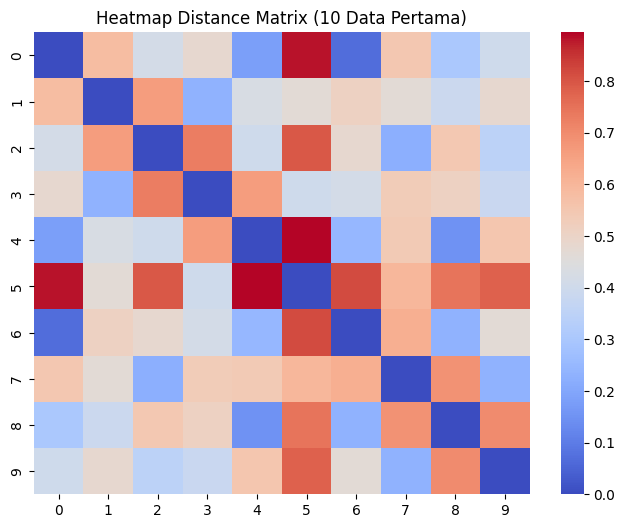

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(distance_df.iloc[:10,:10], cmap="coolwarm")
plt.title("Heatmap Distance Matrix (10 Data Pertama)")
plt.show()

### Interpretasi Heatmap

Heatmap menunjukkan tingkat kemiripan antar data mahasiswa.

- Warna biru menunjukkan jarak yang kecil (data lebih mirip)
- Warna merah menunjukkan jarak yang besar (data lebih berbeda)

## Kesimpulan

Berdasarkan analisis yang dilakukan, dataset mahasiswa memiliki tipe data campuran yang terdiri dari numerik, ordinal, kategorikal, dan binary.

Untuk menghitung jarak antar data digunakan metode **Gower Distance** yang mampu menangani tipe data campuran.

Hasil perhitungan jarak disajikan dalam bentuk **distance matrix** yang menunjukkan tingkat kemiripan antar objek data.